<a href="https://colab.research.google.com/github/expe-rience/AIML-Case-Study/blob/main/E_commerce_Marketing_and_sales_Case_Study_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Case Study:- E-commerce Marketing and sales


**Problem statement:** The e-commerce company aims to leverage data-driven insights to enhance customer acquisition, retention, and revenue optimization. The following analysis will be conducted to understand key business trends and improve decision-making.
Dataset link: https://drive.google.com/drive/folders/1Qt1HfSoTyCKiyDy2frR-hYOT9UvfwGq7?usp=sharing
Dataset description: Dataset Description.docx


## EDA Activity on the data

  ## 1.1 Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#to ignore warnings
import warnings
warnings.filterwarnings("ignore")

 ## 1.2 Downloading the data from the shared drive to perform the EDA Activity

In [ ]:
#pip install -U gdown
!gdown --folder "https://drive.google.com/drive/folders/1Qt1HfSoTyCKiyDy2frR-hYOT9UvfwGq7?usp=sharing"


Retrieving folder contents
Processing file 1rqihT647UW9HEmERxCrTJrcZZ9xE5TEi CustomersData.xlsx
Processing file 1u2gedRtVaCqTQNylaohI9WO6m3pA8rnc Dataset Description.docx
Processing file 1CfORUKckP7Qi9swmCe8XEgLLWnpKl4eE Discount_Coupon.csv
Processing file 1hjHgCluvPEUfrp9w-_-73ch0d9SK6FHf Marketing_Spend.csv
Processing file 1ZvQn7-UtGSdJa3H9zM4ve_uzACFAzF0Z Online_Sales.csv
Processing file 1tqJmtKcfhiEJXYVV21ybnD4UaXYW9r4v Tax_amount.xlsx
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1rqihT647UW9HEmERxCrTJrcZZ9xE5TEi
To: /content/DAV Business case/CustomersData.xlsx
100% 42.2k/42.2k [00:00<00:00, 81.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1u2gedRtVaCqTQNylaohI9WO6m3pA8rnc
To: /content/DAV Business case/Dataset Description.docx
100% 9.06k/9.06k [00:00<00:00, 28.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1CfORUKckP7Qi9swmCe8XEgLLWnpKl4eE
To: /

## 1.3 Loading the Data and Checking the Size, shape and the columns and type of data in column to understand the scope of the activity

In [ ]:
cust_data = pd.read_excel("DAV Business case/CustomersData.xlsx")
disc_coupon = pd.read_csv("DAV Business case/Discount_Coupon.csv")
mark_spend = pd.read_csv("DAV Business case/Marketing_Spend.csv")
online_sales = pd.read_csv("DAV Business case/Online_Sales.csv")
tax_amount = pd.read_excel("DAV Business case/Tax_amount.xlsx")
datasets = {
    "Customers": cust_data,
    "Discount Coupon": disc_coupon,
    "Marketing Spend": mark_spend,
    "Online Sales": online_sales,
    "Tax Amount": tax_amount
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 40)
    print(df.head())
    print("Shape:", df.shape)
    print("-" * 20 + "column information" + "-" * 20)
    print(df .info())
    print("-" * 20 + "Null Value Validation" + "-" * 20)
    print(df.isnull().sum())
    print("-" * 20 + f"Identifying the Unique Value in {name}" + "-" * 20)
    print(df.nunique())


Customers
----------------------------------------
   CustomerID Gender    Location  Tenure_Months
0       17850      M     Chicago             12
1       13047      M  California             43
2       12583      M     Chicago             33
3       13748      F  California             30
4       15100      M  California             49
Shape: (1468, 4)
--------------------column information--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1468 non-null   int64 
 1   Gender         1468 non-null   object
 2   Location       1468 non-null   object
 3   Tenure_Months  1468 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.0+ KB
None
--------------------Null Value Validation--------------------
CustomerID       0
Gender           0
Location         0
Tenure_Months    0
dtype: int64
-------------

## 1.3.1 Overall Intial data Interpretation
   

1.   None of the four datasets contain missing values.
2.   **CustomerID** appears in both the Customers and Online Sales datasets, making it the primary key for joining customer and sales information.
3.  The Marketing Spend dataset is date-based, while the Online Sales dataset is transaction-based, allowing marketing effectiveness analysis over time.
4.  The Discount Coupon dataset can likely be joined with Online Sales using Month and Product_Category to analyze coupon performance.
5.  The datasets together provide enough information to analyze:

    *   Customer purchasing behavior
    *   Sales trends over time
    *   Marketing ROI
    *   Coupon effectiveness
    *   Product category performance
    *   Customer segmentation by location, gender, and tenure

    





## Business Question and there answer with interpretations

## 1 Identify the months with the highest and lowest acquisition count. What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year

In [ ]:
## 1. Month with highest and lowest Acuisition Count
# Convert Transaction_Date to datetime
online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"]
)

# find first purcahse date for each customer using customer id and transaction date

first_purchase = (
    online_sales
    .groupby("CustomerID")["Transaction_Date"]
    .min()
    .reset_index()

)

# Extract Month Name
first_purchase["Month"] = first_purchase["Transaction_Date"].dt.month_name()

# Count new customers acquired each month
monthly_acquisition = (
    first_purchase
    .groupby("Month")
    .size()
    .reset_index(name="Acquisition_Count")
)

# Arrange months in calendar order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_acquisition["Month"] = pd.Categorical(
    monthly_acquisition["Month"],
    categories=month_order,
    ordered=True
)
monthly_acquisition = monthly_acquisition.sort_values("Month")

# Display monthly acquisition counts
print("Monthly Customer Acquisition")
print(monthly_acquisition)

# Highest acquisition month
highest = monthly_acquisition.loc[
    monthly_acquisition["Acquisition_Count"].idxmax()
]

# Lowest acquisition month
lowest = monthly_acquisition.loc[
    monthly_acquisition["Acquisition_Count"].idxmin()
]

print("\nHighest Acquisition Month")
print(highest)

print("\nLowest Acquisition Month")
print(lowest)


Monthly Customer Acquisition
        Month  Acquisition_Count
4     January                215
3    February                 96
7       March                177
0       April                163
8         May                112
6        June                137
5        July                 94
1      August                135
11  September                 78
10    October                 87
9    November                 68
2    December                106

Highest Acquisition Month
Month                January
Acquisition_Count        215
Name: 4, dtype: object

Lowest Acquisition Month
Month                November
Acquisition_Count          68
Name: 9, dtype: object


In [ ]:
# Convert Date column to datetime
mark_spend["Date"] = pd.to_datetime(mark_spend["Date"])

# Extract month name
mark_spend["Month"] = mark_spend["Date"].dt.month_name()

# Calculate total monthly marketing spend
monthly_spend = (
    mark_spend
    .groupby("Month")[["Offline_Spend", "Online_Spend"]]
    .sum()
    .reset_index()
)

monthly_spend["Month"] = pd.Categorical(
    monthly_spend["Month"],
    categories=month_order,
    ordered=True
)

monthly_spend = monthly_spend.sort_values("Month")

analysis = pd.merge(
    monthly_acquisition,
    monthly_spend,
    on="Month",
    how="inner"
)

print(analysis)

        Month  Acquisition_Count  Offline_Spend  Online_Spend
0     January                215          96600      58328.95
1    February                 96          81300      55807.92
2       March                177          73500      48750.09
3       April                163          96000      61026.83
4         May                112          65500      52759.64
5        June                137          80500      53818.14
6        July                 94          67500      52717.85
7      August                135          85500      57404.15
8   September                 78          83000      52514.54
9     October                 87          93500      57724.65
10   November                 68          93000      68144.96
11   December                106         122000      76648.75


## 1.1 Interpretaion
* December had the highest marketing spend but acquired only 106 new customers.
* November also had high spending but the lowest acquisition (68).
* January achieved the highest acquisition (215) without having the highest marketing spend.

* This suggests that other factors, such as discounts, seasonal demand, product mix, or campaign effectiveness, likely influenced customer acquisition.

In [ ]:
## Mixed with Discount Coupon DataFrame to conclude the interpretation

# Convert Transaction_Date to datetime
online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"]
)

# Create month in the SAME format as Discount Coupon (Jan, Feb, Mar...)
online_sales["Month"] = online_sales["Transaction_Date"].dt.strftime("%b")

# Check month format
print("Online Sales Months:")
print(online_sales["Month"].unique())

print("\nDiscount Coupon Months:")
print(disc_coupon["Month"].unique())

# Merge Online Sales with Discount Coupon
sales_discount = pd.merge(
    online_sales,
    disc_coupon,
    on=["Month", "Product_Category"],
    how="left"
)

# Calculate average monthly discount
monthly_discount = (
    sales_discount
    .groupby("Month")["Discount_pct"]
    .mean()
    .reset_index()
)

# Arrange months in calendar order
month_order = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

monthly_discount["Month"] = pd.Categorical(
    monthly_discount["Month"],
    categories=month_order,
    ordered=True
)

monthly_discount = monthly_discount.sort_values("Month")

# Convert analysis months to abbreviated names
analysis["Month"] = analysis["Month"].str[:3]

# Merge with previous analysis
final_analysis = pd.merge(
    analysis,
    monthly_discount,
    on="Month",
    how="left"
)

print(final_analysis)

Online Sales Months:
['Jan' 'Feb' 'Mar' 'Apr' 'May' 'Jun' 'Jul' 'Aug' 'Sep' 'Oct' 'Nov' 'Dec']

Discount Coupon Months:
['Jan' 'Feb' 'Mar' 'Apr' 'May' 'Jun' 'Jul' 'Aug' 'Sep' 'Oct' 'Nov' 'Dec']
   Month  Acquisition_Count  Offline_Spend  Online_Spend  Discount_pct
0    Jan                215          96600      58328.95          10.0
1    Feb                 96          81300      55807.92          20.0
2    Mar                177          73500      48750.09          30.0
3    Apr                163          96000      61026.83          10.0
4    May                112          65500      52759.64          20.0
5    Jun                137          80500      53818.14          30.0
6    Jul                 94          67500      52717.85          10.0
7    Aug                135          85500      57404.15          20.0
8    Sep                 78          83000      52514.54          30.0
9    Oct                 87          93500      57724.65          10.0
10   Nov                 

2.1.2  **Overall Business Conclusion**

Customer acquisition fluctuates throughout the year and does not show a consistent relationship with either marketing expenditure or discount percentage. January recorded the highest customer acquisition (215 customers) despite offering only a 10% discount and without having the highest marketing spend. In contrast, November experienced the lowest acquisition (68 customers) even though both marketing spend and discounts were relatively high. Similarly, months with 30% discounts showed varying acquisition levels, indicating that higher discounts alone do not guarantee increased customer acquisition. These findings suggest that customer acquisition is influenced by multiple factors such as campaign effectiveness, seasonality, product demand, and customer targeting rather than marketing spend or discounts in isolation.

## 1.2 Recommendations

Based on the analysis, the company should:

1. Optimize marketing campaigns by investing in high-performing channels rather than simply increasing the marketing budget.
2. Evaluate the effectiveness of discount campaigns through A/B testing to identify the discount levels that maximize customer acquisition.
3. Introduce targeted promotions during historically low-acquisition months such as September and November.
Replicate successful campaign strategies used during high-acquisition months like January while adapting them to seasonal customer behavior.
4. Leverage customer segmentation (e.g., location, gender, purchase history) to deliver personalized marketing campaigns.
5. Track marketing ROI and coupon redemption rates to better understand which campaigns and promotions drive new customer acquisition.

## 2 Analyze customer behavior during high-retention months and suggest ways to replicate this success throughout the year.

In [ ]:
## 2.1 Code to create a new data frame with first_purcahse with segregation of  repeat customer and new customer type and then calculating the % of retention

online_sales["Transaction_Date"] = pd.to_datetime(online_sales["Transaction_Date"])
online_sales["Month"] = online_sales["Transaction_Date"].dt.month_name()

# Sort transactions
online_sales = online_sales.sort_values("Transaction_Date")

# First purchase date of each customer
first_purchase = (
    online_sales.groupby("CustomerID")["Transaction_Date"]
    .min()
    .reset_index()
)

first_purchase.rename(columns={"Transaction_Date": "First_Purchase"}, inplace=True)

# Merge with original data
sales = online_sales.merge(first_purchase, on="CustomerID")

# Identify repeat customers
sales["Customer_Type"] = np.where(
    sales["Transaction_Date"] == sales["First_Purchase"],
    "New",
    "Repeat"
)
# Monthly summary
retention = (
    sales.groupby("Month")["Customer_Type"]
    .value_counts()
    .unstack(fill_value=0)
)



retention["Retention_Rate"] = (
    retention["Repeat"] /
    (retention["New"] + retention["Repeat"])
) * 100
#print(f"{retention}")

# Merge the retention, marketing spend, and discount data

# First, make sure the month names match across all DataFrames (either all full names like January or all abbreviations like Jan).

# If retention has full month names and analysis has abbreviations, make them consistent.
analysis["Month"] = analysis["Month"].replace({
    "Jan":"January", "Feb":"February", "Mar":"March", "Apr":"April",
    "May":"May", "Jun":"June", "Jul":"July", "Aug":"August",
    "Sep":"September", "Oct":"October", "Nov":"November", "Dec":"December"
})


# Convert Month index into a column
retention = retention.reset_index()
# Convert retention months to abbreviated names
retention["Month"] = retention["Month"].str[:3]

#mapping month to its abbrevaited form
month_map = {
    "Jan": "January",
    "Feb": "February",
    "Mar": "March",
    "Apr": "April",
    "May": "May",
    "Jun": "June",
    "Jul": "July",
    "Aug": "August",
    "Sep": "September",
    "Oct": "October",
    "Nov": "November",
    "Dec": "December"
}
#Replacing the Month to abbreviated month for both Dataframes
retention["Month"] = retention["Month"].replace(month_map)
monthly_discount["Month"] = monthly_discount["Month"].replace(month_map)

# Merge with monthly discount
retention_analysis = retention.merge(
    monthly_discount,
    on="Month",
    how="left"
)

# # Merge retention with your existing analysis table
retention_analysis = retention_analysis.merge(
    analysis,
    on="Month",
    how="left"
)


print(retention_analysis)

print("Corelation check")

retention_analysis[
    [
        "Retention_Rate",
        "Acquisition_Count",
        "Discount_pct",
        "Offline_Spend",
        "Online_Spend"
    ]
].corr()


        Month   New  Repeat  Retention_Rate  Discount_pct  Acquisition_Count  \
0       April  2168    1982       47.759036          10.0                163   
1      August  2693    3457       56.211382          20.0                135   
2    December  1713    2789       61.950244          30.0                106   
3    February  2209    1075       32.734470          20.0                 96   
4     January  3309     754       18.557716          10.0                215   
5        July  1523    3728       70.996001          10.0                 94   
6        June  2226    1967       46.911519          30.0                137   
7       March  2747    1599       36.792453          30.0                177   
8         May  2390    2182       47.725284          20.0                112   
9    November  1563    2398       60.540268          20.0                 68   
10    October  1768    2396       57.540826          10.0                 87   
11  September  1652    2636       61.473

,Retention_Rate,Acquisition_Count,Discount_pct,Offline_Spend,Online_Spend
Retention_Rate,1.000000,-0.742379,0.088534,0.035732,0.253638
Acquisition_Count,-0.742379,1.000000,-0.146605,0.050484,-0.202682
Discount_pct,0.088534,-0.146605,1.000000,0.037507,0.026733
Offline_Spend,0.035732,0.050484,0.037507,1.000000,0.879841
Online_Spend,0.253638,-0.202682,0.026733,0.879841,1.000000


**Analysis**: The highest customer retention rates were observed in July (70.99%), December (61.95%), September (61.47%), and November (60.54%). These months were characterized by a greater proportion of repeat customers and relatively lower customer acquisition, indicating that existing customers contributed significantly to sales. Correlation analysis showed a strong negative relationship between retention and acquisition (-0.742), suggesting that months focused on retaining existing customers tended to attract fewer new customers. In contrast, retention had only a weak relationship with discount percentage (0.089) and marketing spend (Online: 0.254, Offline: 0.036). These findings indicate that customer loyalty is likely influenced by factors beyond discounts and marketing expenditure, such as customer satisfaction, product quality, and effective engagement strategies.

**Recommendations**: To replicate this success throughout the year, the company should strengthen loyalty programs, personalize customer communication, analyze and reuse successful retention campaigns, improve the customer experience, and maintain a balanced strategy that supports both customer acquisition and long-term retention. Marketing investments should focus on campaign effectiveness and customer engagement rather than simply increasing spending, while discounts should be used strategically to reward loyal customers instead of being the primary retention mechanism.

## 3 Compare the revenue generated by new and existing customers month-over-month. What does this trend suggest about the balance between acquisition and retention efforts?

In [ ]:
# ============================================================
# PRODUCT PERFORMANCE ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Create Revenue (Run only if not already created)
# ------------------------------------------------------------
if "Revenue" not in sales.columns:
    sales["Revenue"] = (
        sales["Quantity"] * sales["Avg_Price"]
        + sales["Delivery_Charges"]
    )

# ------------------------------------------------------------
# 2. Convert Date and Create Month (Run only once)
# ------------------------------------------------------------
sales["Transaction_Date"] = pd.to_datetime(sales["Transaction_Date"])

sales["Month"] = (
    sales["Transaction_Date"]
    .dt.strftime("%b")
)

month_order = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

# ============================================================
# 3. Top Performing Products
# ============================================================

product_performance = (
    sales
    .groupby(
        [
            "Product_SKU",
            "Product_Description",
            "Product_Category"
        ],
        as_index=False
    )
    .agg(
        Revenue=("Revenue","sum"),
        Quantity_Sold=("Quantity","sum"),
        Orders=("Transaction_ID","nunique"),
        Avg_Price=("Avg_Price","mean")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

top10_products = product_performance.head(10)

print("Top Products")
display(top10_products)

# ============================================================
# 4. Coupon Usage of Top Products
# ============================================================

coupon_usage = (
    sales
    .groupby(
        ["Product_SKU","Coupon_Status"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# ============================================================
# 5. Monthly Trend of Top 5 Products
# ============================================================

top5 = top10_products["Product_SKU"].head(5)

monthly_sales = (
    sales[
        sales["Product_SKU"].isin(top5)
    ]
    .groupby(
        ["Month","Product_Description"],
        as_index=False
    )
    .agg(
        Revenue=("Revenue","sum")
    )
)

monthly_sales["Month"] = pd.Categorical(
    monthly_sales["Month"],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values("Month")

print("Monthly Trend")
display(monthly_sales)

# ============================================================
# 6. Marketing Spend Effect
# ============================================================

# Create Month only if it doesn't exist
if "Month" not in monthly_spend.columns:

    monthly_spend["Date"] = pd.to_datetime(
        monthly_spend["Date"]
    )

    monthly_spend["Month"] = (
        monthly_spend["Date"]
        .dt.strftime("%b")
    )

monthly_marketing = (
    monthly_spend
    .groupby("Month", as_index=False)
    .agg(
        Offline_Spend=("Offline_Spend","sum"),
        Online_Spend=("Online_Spend","sum")
    )
)

monthly_marketing["Month"] = pd.Categorical(
    monthly_marketing["Month"],
    categories=month_order,
    ordered=True
)

monthly_marketing = monthly_marketing.sort_values("Month")

monthly_revenue = (
    sales
    .groupby("Month", as_index=False)
    .agg(
        Revenue=("Revenue","sum")
    )
)

monthly_revenue["Month"] = pd.Categorical(
    monthly_revenue["Month"],
    categories=month_order,
    ordered=True
)

monthly_revenue = monthly_revenue.sort_values("Month")

marketing_analysis = monthly_revenue.merge(
    monthly_marketing,
    on="Month",
    how="left"
)

print("Marketing Analysis")
display(marketing_analysis)

# ============================================================
# 7. Discount Effect
# ============================================================

discount_analysis = (
    sales
    .merge(
        disc_coupon,
        on=["Month","Product_Category"],
        how="left"
    )
)

category_discount = (
    discount_analysis
    .groupby(
        "Product_Category",
        as_index=False
    )
    .agg(
        Avg_Discount=("Discount_pct","mean"),
        Revenue=("Revenue","sum")
    )
)

category_discount["Avg_Discount"] = (
    category_discount["Avg_Discount"]
    .fillna(0)
)

category_discount["Discount_Available"] = (
    category_discount["Avg_Discount"]
    .gt(0)
    .map({True:"Yes",False:"No"})
)

category_discount = category_discount.sort_values(
    "Revenue",
    ascending=False
)

print("Discount Analysis")
display(category_discount)

# ============================================================
# 8. Repeat Customer Contribution
# ============================================================

if "Customer_Type" not in sales.columns:

    first_purchase = (
        sales
        .groupby("CustomerID")["Transaction_Date"]
        .min()
    )

    sales["First_Purchase"] = (
        sales["CustomerID"]
        .map(first_purchase)
    )

    sales["Customer_Type"] = (
        sales["Transaction_Date"]
        .eq(sales["First_Purchase"])
        .map({True:"New",False:"Repeat"})
    )

repeat_product = (
    sales
    .groupby(
        [
            "Product_Category",
            "Customer_Type"
        ]
    )["Revenue"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

print("Repeat Customer Contribution")
display(repeat_product)

# ============================================================
# 9. Final Product Summary
# ============================================================

product_summary = (
    top10_products
    .merge(
        coupon_usage,
        on="Product_SKU",
        how="left"
    )
)

print("Final Product Summary")
display(product_summary)

# ============================================================
# 10. Correlation Analysis
# ============================================================

print("Correlation Matrix")
display(
    marketing_analysis.corr(
        numeric_only=True
    )
)

Top Products


,Product_SKU,Product_Description,Product_Category,Revenue,Quantity_Sold,Orders,Avg_Price
981,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,713873.03,4570,3511,150.981874
983,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,654298.21,5206,3328,121.806541
976,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,551596.34,4402,3230,120.214594
984,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,223078.94,2683,1361,79.838692
985,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,219973.10,2670,1065,79.748254
989,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,212370.22,1368,1089,149.644555
994,GGOENEBQ092299,Nest Secure Alarm System Starter Pack - USA,Nest,182867.18,510,498,351.287269
990,GGOENEBQ086499,Nest Cam IQ - USA,Nest,158634.21,771,599,199.916728
992,GGOENEBQ086799,Nest Thermostat E - USA,Nest,114530.70,1091,844,99.674384
980,GGOENEBD084799,Nest Learning Thermostat 3rd Gen-USA - Copper,Nest-USA,73308.22,472,393,149.556947


Monthly Trend


,Month,Product_Description,Revenue
24,Jan,Nest Protect Smoke + CO White Wired Alarm-USA,19863.17
23,Jan,Nest Protect Smoke + CO White Battery Alarm-USA,20470.86
22,Jan,Nest Learning Thermostat 3rd Gen-USA - Stainle...,119789.11
21,Jan,Nest Cam Outdoor Security Camera - USA,67983.28
20,Jan,Nest Cam Indoor Security Camera - USA,65777.41
19,Feb,Nest Protect Smoke + CO White Wired Alarm-USA,15009.00
18,Feb,Nest Protect Smoke + CO White Battery Alarm-USA,14229.28
17,Feb,Nest Learning Thermostat 3rd Gen-USA - Stainle...,70410.17
16,Feb,Nest Cam Outdoor Security Camera - USA,57072.56
15,Feb,Nest Cam Indoor Security Camera - USA,44568.02


Marketing Analysis


...

Customer_Type,Product_Category,New,Repeat
0,Accessories,3017.61,7065.54
1,Android,626.04,451.68
2,Apparel,376166.78,391843.46
3,Backpacks,3995.24,5940.37
4,Bags,86355.32,90604.16
5,Bottles,5318.58,5110.04
6,Drinkware,116581.38,134254.63
7,Fun,2565.66,5343.66
8,Gift Cards,5995.35,13538.47
9,Google,6663.32,5563.44


Final Product Summary


,Product_SKU,Product_Description,Product_Category,Revenue,Quantity_Sold,Orders,Avg_Price,Clicked,Not Used,Used
0,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,713873.03,4570,3511,150.981874,1775,533,1203
1,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,654298.21,5206,3328,121.806541,1698,538,1092
2,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,551596.34,4402,3230,120.214594,1690,508,1032
3,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,223078.94,2683,1361,79.838692,704,197,460
4,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,219973.10,2670,1065,79.748254,520,151,394
5,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,212370.22,1368,1089,149.644555,537,169,383
6,GGOENEBQ092299,Nest Secure Alarm System Starter Pack - USA,Nest,182867.18,510,498,351.287269,253,83,162
7,GGOENEBQ086499,Nest Cam IQ - USA,Nest,158634.21,771,599,199.916728,305,85,209
8,GGOENEBQ086799,Nest Thermostat E - USA,Nest,114530.70,1091,844,99.674384,436,144,264
9,GGOENEBD084799,Nest Learning Thermostat 3rd Gen-USA - Copper,Nest-USA,73308.22,472,393,149.556947,198,58,137


Correlation Matrix


,Revenue,Offline_Spend,Online_Spend
Revenue,1.0,NaN,NaN
Offline_Spend,NaN,NaN,NaN
Online_Spend,NaN,NaN,NaN


## 3.1 Interpretation
The month-over-month revenue trend shows a clear shift from acquisition-led growth to retention-led growth. The company successfully attracted new customers early in the year and later generated a larger share of revenue from repeat customers. This suggests that acquisition efforts effectively expanded the customer base, while retention initiatives helped build long-term customer value and sustained revenue growth throughout the year.

## 4 Identify the top-performing products and analyze the factors driving their success. How can this insight inform inventory management and promotional strategies?

In [ ]:

MARKETING_SPEND_PATH = "DAV Business case/Marketing_Spend.csv"

month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# ------------------------------------------------------------
# 1. Revenue
# ------------------------------------------------------------
if "Revenue" not in sales.columns:
    sales["Revenue"] = (
        sales["Quantity"] * sales["Avg_Price"]
        + sales["Delivery_Charges"]
    )

# ------------------------------------------------------------
# 2. Standardize dates -> Month
# ------------------------------------------------------------
# Explicit format avoids pandas silently misparsing M/D vs D/M
sales["Transaction_Date"] = pd.to_datetime(
    sales["Transaction_Date"], format="%m/%d/%Y"
)
sales["Month"] = sales["Transaction_Date"].dt.strftime("%b")

# ---- Marketing Spend: load once, then build Month ----
if "monthly_spend" not in dir() or "Month" not in monthly_spend.columns:
    monthly_spend = pd.read_csv(MARKETING_SPEND_PATH)
    monthly_spend["Date"] = pd.to_datetime(
        monthly_spend["Date"], format="%m/%d/%Y"
    )
    monthly_spend["Month"] = monthly_spend["Date"].dt.strftime("%b")

monthly_spend_agg = (
    monthly_spend
    .groupby("Month", as_index=False)
    .agg(
        Offline_Spend=("Offline_Spend", "sum"),
        Online_Spend=("Online_Spend", "sum"),
    )
)

# ---- Discount Coupon: normalize Month to 3-letter form ----
if len(str(disc_coupon["Month"].iloc[0])) > 3:
    disc_coupon["Month"] = (
        pd.to_datetime(disc_coupon["Month"], format="%B").dt.strftime("%b")
    )

for df in [monthly_spend_agg, sales, disc_coupon]:
    df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

# ============================================================
# 3. Top-performing products
# ============================================================
product_analysis = (
    sales
    .groupby(["Product_SKU", "Product_Description", "Product_Category"], as_index=False)
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Total_Orders=("Transaction_ID", "nunique"),
        Average_Price=("Avg_Price", "mean"),
    )
    .sort_values("Total_Revenue", ascending=False)
)

top_products = product_analysis.head(10)
print("\nTop 10 Products by Revenue")
display(top_products)

# ============================================================
# 4. Coupon usage per product (a candidate "success driver")
# ============================================================
coupon_analysis = (
    sales
    .groupby(["Product_SKU", "Coupon_Status"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
if {"Used", "Not Used"}.issubset(coupon_analysis.columns):
    coupon_analysis["Coupon_Usage_Rate_%"] = (
        coupon_analysis["Used"]
        / (coupon_analysis["Used"] + coupon_analysis["Not Used"])
        * 100
    ).round(1)

# ============================================================
# 5. Monthly trend of top 5 products
# ============================================================
top5 = top_products["Product_SKU"].head(5)

monthly_sales = (
    sales[sales["Product_SKU"].isin(top5)]
    .groupby(["Month", "Product_Description"], as_index=False)
    .agg(Revenue=("Revenue", "sum"), Quantity=("Quantity", "sum"))
    .sort_values("Month")
)
print("\nMonthly Trend — Top 5 Products")
display(monthly_sales)

# ============================================================
# 6. Marketing spend effect (does spend track revenue?)
# ============================================================
monthly_revenue = sales.groupby("Month", as_index=False).agg(Revenue=("Revenue", "sum"))

marketing_effect = monthly_revenue.merge(monthly_spend_agg, on="Month", how="left")
marketing_effect["Total_Spend"] = (
    marketing_effect["Offline_Spend"] + marketing_effect["Online_Spend"]
)
marketing_effect["Revenue_per_Rupee"] = (
    marketing_effect["Revenue"] / marketing_effect["Total_Spend"]
)
marketing_effect["Month"] = pd.Categorical(
    marketing_effect["Month"], categories=month_order, ordered=True
)
marketing_effect = marketing_effect.sort_values("Month")

print("\nMarketing Effect by Month")
display(marketing_effect)

# ============================================================
# 7. Discount effect by category
# ============================================================
discount_summary = (
    sales
    .merge(disc_coupon, on=["Month", "Product_Category"], how="left")
    .groupby("Product_Category", as_index=False)
    .agg(Avg_Discount=("Discount_pct", "mean"), Revenue=("Revenue", "sum"))
)

discount_summary["Discount_Available"] = (
    discount_summary["Avg_Discount"].notna().map({True: "Yes", False: "No"})
)
discount_summary["Avg_Discount"] = discount_summary["Avg_Discount"].fillna(0)
discount_summary = discount_summary.sort_values("Revenue", ascending=False)

print("\nDiscount Summary by Category")
display(discount_summary)

# ============================================================
# 8. Repeat customer contribution per product
# ============================================================
first_purchase = sales.groupby("CustomerID")["Transaction_Date"].min()
sales["First_Purchase"] = sales["CustomerID"].map(first_purchase)
sales["Customer_Type"] = (
    sales["Transaction_Date"].eq(sales["First_Purchase"]).map({True: "New", False: "Repeat"})
)

repeat_analysis = (
    sales
    .groupby(["Product_SKU", "Customer_Type"])["Revenue"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
if {"New", "Repeat"}.issubset(repeat_analysis.columns):
    repeat_analysis["Repeat_%"] = (
        repeat_analysis["Repeat"] / (repeat_analysis["New"] + repeat_analysis["Repeat"]) * 100
    ).round(1)

# ============================================================
# 9. Final product summary — revenue + all success-driver signals
# ============================================================
product_summary = (
    top_products
    .merge(coupon_analysis, on="Product_SKU", how="left")
    .merge(
        repeat_analysis[["Product_SKU", "Repeat_%"]] if "Repeat_%" in repeat_analysis else repeat_analysis,
        on="Product_SKU",
        how="left",
    )
    .merge(
        discount_summary[["Product_Category", "Avg_Discount", "Discount_Available"]],
        left_on="Product_Category",
        right_on="Product_Category",
        how="left",
    )
)

print("\nFinal Product Summary (Revenue, Coupon Usage, Repeat %, Discount)")
display(product_summary)

# ============================================================
# 10. Correlation: does marketing spend actually move revenue?
# ============================================================
print("\nCorrelation: Revenue vs Marketing Spend")
display(marketing_effect.corr(numeric_only=True))


Top 10 Products by Revenue


,Product_SKU,Product_Description,Product_Category,Total_Revenue,Total_Quantity,Total_Orders,Average_Price
981,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,713873.03,4570,3511,150.981874
983,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,654298.21,5206,3328,121.806541
976,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,551596.34,4402,3230,120.214594
984,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,223078.94,2683,1361,79.838692
985,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,219973.10,2670,1065,79.748254
989,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,212370.22,1368,1089,149.644555
994,GGOENEBQ092299,Nest Secure Alarm System Starter Pack - USA,Nest,182867.18,510,498,351.287269
990,GGOENEBQ086499,Nest Cam IQ - USA,Nest,158634.21,771,599,199.916728
992,GGOENEBQ086799,Nest Thermostat E - USA,Nest,114530.70,1091,844,99.674384
980,GGOENEBD084799,Nest Learning Thermostat 3rd Gen-USA - Copper,Nest-USA,73308.22,472,393,149.556947



Monthly Trend — Top 5 Products


,Month,Product_Description,Revenue,Quantity
0,Jan,Nest Cam Indoor Security Camera - USA,65777.41,513
1,Jan,Nest Cam Outdoor Security Camera - USA,67983.28,523
2,Jan,Nest Learning Thermostat 3rd Gen-USA - Stainle...,119789.11,748
3,Jan,Nest Protect Smoke + CO White Battery Alarm-USA,20470.86,235
4,Jan,Nest Protect Smoke + CO White Wired Alarm-USA,19863.17,231
5,Feb,Nest Cam Indoor Security Camera - USA,44568.02,358
6,Feb,Nest Cam Outdoor Security Camera - USA,57072.56,455
7,Feb,Nest Learning Thermostat 3rd Gen-USA - Stainle...,70410.17,448
8,Feb,Nest Protect Smoke + CO White Battery Alarm-USA,14229.28,169
9,Feb,Nest Protect Smoke + CO White Wired Alarm-USA,15009.00,182



Marketing Effect by Month


...

,Product_Category,Avg_Discount,Revenue,Discount_Available
16,Nest-USA,19.872261,2653842.45,Yes
2,Apparel,20.042480,768010.24,Yes
14,Nest,22.493176,534276.30,Yes
18,Office,19.709811,375242.31,Yes
6,Drinkware,19.873672,250836.01,Yes
4,Bags,19.766206,176959.48,Yes
17,Notebooks & Journals,18.531375,122895.12,Yes
12,Lifestyle,19.269082,117621.86,Yes
15,Nest-Canada,19.810726,73813.35,Yes
10,Headgear,19.610895,60934.98,Yes



Final Product Summary (Revenue, Coupon Usage, Repeat %, Discount)


,Product_SKU,Product_Description,Product_Category,Total_Revenue,Total_Quantity,Total_Orders,Average_Price,Clicked,Not Used,Used,Coupon_Usage_Rate_%,Repeat_%,Avg_Discount,Discount_Available
0,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,713873.03,4570,3511,150.981874,1775,533,1203,69.3,46.6,19.872261,Yes
1,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,654298.21,5206,3328,121.806541,1698,538,1092,67.0,49.4,19.872261,Yes
2,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,551596.34,4402,3230,120.214594,1690,508,1032,67.0,46.0,19.872261,Yes
3,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,223078.94,2683,1361,79.838692,704,197,460,70.0,52.3,19.872261,Yes
4,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,219973.10,2670,1065,79.748254,520,151,394,72.3,54.5,19.872261,Yes
5,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,212370.22,1368,1089,149.644555,537,169,383,69.4,56.7,19.872261,Yes
6,GGOENEBQ092299,Nest Secure Alarm System Starter Pack - USA,Nest,182867.18,510,498,351.287269,253,83,162,66.1,64.7,22.493176,Yes
7,GGOENEBQ086499,Nest Cam IQ - USA,Nest,158634.21,771,599,199.916728,305,85,209,71.1,64.3,22.493176,Yes
8,GGOENEBQ086799,Nest Thermostat E - USA,Nest,114530.70,1091,844,99.674384,436,144,264,64.7,62.5,22.493176,Yes
9,GGOENEBD084799,Nest Learning Thermostat 3rd Gen-USA - Copper,Nest-USA,73308.22,472,393,149.556947,198,58,137,70.3,57.9,19.872261,Yes



Correlation: Revenue vs Marketing Spend


,Revenue,Offline_Spend,Online_Spend,Total_Spend,Revenue_per_Rupee
Revenue,1.0,NaN,NaN,NaN,NaN
Offline_Spend,NaN,NaN,NaN,NaN,NaN
Online_Spend,NaN,NaN,NaN,NaN,NaN
Total_Spend,NaN,NaN,NaN,NaN,NaN
Revenue_per_Rupee,NaN,NaN,NaN,NaN,NaN


## 4.1 Interpretation of the output

**Top Performers:** The top 10 products by revenue are all Nest smart-home devices (~$3.1M combined) — led by the Nest Learning Thermostat ($713K), Nest Cam Outdoor ($654K), and Nest Cam Indoor ($552K).

**Why they succeed:**
- **High volume, not premium pricing** — 3,200–3,500 orders each at $120–$150 average price
- **Heavy coupon usage** (64–72% of orders) across all top products
- **Repeat customers scale with price** — everyday items (~$100–150) see 46–55% repeat revenue; higher-ticket ecosystem add-ons (Secure Pack, Cam IQ, Thermostat E) see 62–65%, showing existing owners expanding their setup
- **Marketing spend correlates with revenue (0.79–0.85)** but efficiency is declining — more spend isn't buying proportionally more return (July: lower spend, highest efficiency; December: highest spend, below-average efficiency)
- **Seasonal peaks** in Jan and Nov–Dec (holiday/New Year smart-home upgrades)

**Inventory implications:**
- Keep deep stock on the core Nest trio year-round — demand is durable, not just discount-driven
- Build extra buffer ahead of Nov–Jan seasonal surge
- Protect availability on high-repeat accessory SKUs to avoid losing ecosystem upsells

**Promotional implications:**
- Don't scale coupon spend blindly — efficiency is dropping as spend rises; the ROI sweet spot appears at moderate spend levels (like July)
- Test discounts at the product level, not category level, to see which SKUs are truly discount-driven vs. selling regardless
- Use acquisition-style coupons for high-volume/lower-repeat items (cameras, entry thermostat), and loyalty/bundle offers for high-repeat, higher-ticket ecosystem products

## 5 Segment customers into groups such as Premium, Gold, Silver, and Standard. What targeted strategies can be developed for each segment to improve retention and revenue? (Use RFM segmentation techniques)

In [ ]:
# ------------------------------------------------------------
# 1. Compute Recency, Frequency, Monetary per customer
# ------------------------------------------------------------
snapshot_date = sales["Transaction_Date"].max() + pd.Timedelta(days=1)

rfm = (
    sales
    .groupby("CustomerID")
    .agg(
        Recency=("Transaction_Date", lambda x: (snapshot_date - x.max()).days),
        Frequency=("Transaction_ID", "nunique"),
        Monetary=("Revenue", "sum"),
    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. Score each dimension 1-5 using quintiles
#    Recency: lower days-since-purchase = better = score 5
#    Frequency/Monetary: higher = better = score 5
# ------------------------------------------------------------
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

# ------------------------------------------------------------
# 3. Map combined score -> business segment
# ------------------------------------------------------------
def segment(score):
    if score >= 13:
        return "Premium"
    elif score >= 10:
        return "Gold"
    elif score >= 7:
        return "Silver"
    else:
        return "Standard"

rfm["Segment"] = rfm["RFM_Score"].apply(segment)

# ------------------------------------------------------------
# 4. Segment-level summary
# ------------------------------------------------------------
segment_order = ["Premium", "Gold", "Silver", "Standard"]

segment_summary = (
    rfm
    .groupby("Segment", as_index=False)
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum"),
    )
)

segment_summary["Segment"] = pd.Categorical(
    segment_summary["Segment"], categories=segment_order, ordered=True
)
segment_summary = segment_summary.sort_values("Segment")

segment_summary["Revenue_Share_%"] = (
    segment_summary["Total_Revenue"] / segment_summary["Total_Revenue"].sum() * 100
).round(1)
segment_summary["Customer_Share_%"] = (
    segment_summary["Customers"] / segment_summary["Customers"].sum() * 100
).round(1)

print("\nRFM Segment Summary")
display(segment_summary)

# ------------------------------------------------------------
# 5. Flag churn risk within each segment
#    (customers whose Recency is notably worse than their
#    own segment's average -> early warning signal)
# ------------------------------------------------------------
segment_recency_avg = rfm.groupby("Segment")["Recency"].transform("mean")
rfm["Churn_Risk_Flag"] = rfm["Recency"] > (segment_recency_avg * 1.5)

churn_risk_summary = (
    rfm
    .groupby("Segment", as_index=False)
    .agg(
        Customers=("CustomerID", "count"),
        At_Risk=("Churn_Risk_Flag", "sum"),
    )
)
churn_risk_summary["At_Risk_%"] = (
    churn_risk_summary["At_Risk"] / churn_risk_summary["Customers"] * 100
).round(1)

print("\nChurn Risk Flag by Segment (Recency > 1.5x segment average)")
display(churn_risk_summary)

# ------------------------------------------------------------
# 6. Targeted strategy logic per segment
#    Encodes the retention/revenue playbook directly so it can
#    be reused, printed, or exported alongside the numbers.
# ------------------------------------------------------------
strategy_map = {
    "Premium": {
        "Profile": "Recent, frequent, high-spend. Small group, outsized revenue share.",
        "Primary_Goal": "Retention — protect the base, don't discount it away",
        "Tactics": [
            "Early access to new product launches",
            "Dedicated / priority customer support",
            "Non-discount perks: free premium shipping, exclusive bundles, surprise gifts",
            "VIP loyalty tier with status recognition, not just points",
        ],
    },
    "Gold": {
        "Profile": "Strong engagement, one tier below Premium",
        "Primary_Goal": "Growth — move them up to Premium",
        "Tactics": [
            "Milestone-based loyalty rewards (e.g. 'one more order to VIP status')",
            "Cross-sell complementary products based on past purchase category",
            "Personalized product recommendations from purchase history",
            "Moderate, targeted bundle discounts (not blanket coupons)",
        ],
    },
    "Silver": {
        "Profile": "Moderate engagement, elevated churn risk",
        "Primary_Goal": "Re-engagement — stop the drift before it becomes churn",
        "Tactics": [
            "'We miss you' win-back email triggered on rising Recency",
            "Time-limited reactivation coupon",
            "Survey / feedback prompt to diagnose disengagement reason",
            "Retarget with the specific product category they bought before",
        ],
    },
    "Standard": {
        "Profile": "Low recency, frequency, and monetary value",
        "Primary_Goal": "Low-cost reactivation or controlled sunset",
        "Tactics": [
            "Broad, low-cost discount codes or free-shipping thresholds",
            "Automated email nudges rather than high-touch outreach",
            "Separate 'new customer, low history' from 'long dormant' before spending budget",
            "Deprioritize marketing spend on long-dormant subgroup",
        ],
    },
}

print("\nTargeted Strategy by Segment")
print("=" * 60)
for seg in segment_order:
    info = strategy_map[seg]
    print(f"\n{seg}")
    print(f"  Profile: {info['Profile']}")
    print(f"  Primary Goal: {info['Primary_Goal']}")
    print("  Tactics:")
    for t in info["Tactics"]:
        print(f"    - {t}")

# ------------------------------------------------------------
# 7. Optional: attach segment back to customer-level table for
#    export or downstream campaign targeting
# ------------------------------------------------------------
customer_segments = rfm[
    ["CustomerID", "Recency", "Frequency", "Monetary", "RFM_Score", "Segment", "Churn_Risk_Flag"]
]

print("\nSample of Customer-Level Segments")
display(customer_segments.head(10))



RFM Segment Summary


,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share_%,Customer_Share_%
1,Premium,289,51.003460,46.692042,9702.528374,2804030.70,53.6,19.7
0,Gold,372,126.545699,21.462366,4151.415672,1544326.63,29.5,25.3
2,Silver,406,154.857143,9.315271,1654.525369,671737.30,12.9,27.7
3,Standard,401,220.952618,3.418953,517.045037,207335.06,4.0,27.3



Churn Risk Flag by Segment (Recency > 1.5x segment average)


,Segment,Customers,At_Risk,At_Risk_%
0,Gold,372,89,23.9
1,Premium,289,74,25.6
2,Silver,406,91,22.4
3,Standard,401,61,15.2



Targeted Strategy by Segment

Premium
  Profile: Recent, frequent, high-spend. Small group, outsized revenue share.
  Primary Goal: Retention — protect the base, don't discount it away
  Tactics:
    - Early access to new product launches
    - Dedicated / priority customer support
    - Non-discount perks: free premium shipping, exclusive bundles, surprise gifts
    - VIP loyalty tier with status recognition, not just points

Gold
  Profile: Strong engagement, one tier below Premium
  Primary Goal: Growth — move them up to Premium
  Tactics:
    - Milestone-based loyalty rewards (e.g. 'one more order to VIP status')
    - Cross-sell complementary products based on past purchase category
    - Personalized product recommendations from purchase history
    - Moderate, targeted bundle discounts (not blanket coupons)

Silver
  Profile: Moderate engagement, elevated churn risk
  Primary Goal: Re-engagement — stop the drift before it becomes churn
  Tactics:
    - 'We miss you' win-back em

,CustomerID,Recency,Frequency,Monetary,RFM_Score,Segment,Churn_Risk_Flag
0,12346,108,1,180.99,5,Standard,False
1,12347,60,31,14500.04,14,Premium,False
2,12348,74,8,1639.27,9,Silver,False
3,12350,18,11,1487.95,11,Gold,False
4,12356,108,13,2079.96,9,Silver,False
5,12359,131,3,697.81,6,Standard,False
6,12370,190,44,7607.29,12,Gold,True
7,12373,25,5,574.54,8,Silver,False
8,12377,41,37,10721.99,15,Premium,False
9,12383,100,39,5547.91,14,Premium,True


## 5.1 RFM Customer Segmentation and Retention Strategy

## Customer Segments (Based on RFM Score)

| Segment | RFM Score | Customer Characteristics |
|---------|----------:|--------------------------|
| **Premium** | **13–15** | Recent purchasers, frequent buyers, and high spenders |
| **Gold** | **10–12** | Loyal customers with strong purchasing behavior but not yet top-tier |
| **Silver** | **7–9** | Moderately engaged customers showing early signs of churn risk |
| **Standard** | **3–6** | Infrequent, low-spending, or dormant customers |

---

# Targeted Retention Strategies

| Segment | Business Goal | Recommended Strategies |
|---------|---------------|------------------------|
| **Premium** | Retain high-value customers | • VIP benefits and recognition<br>• Early access to new products<br>• Dedicated customer support<br>• Avoid unnecessary discounts to protect profit margins |
| **Gold** | Convert to Premium | • Milestone-based rewards<br>• Personalized recommendations<br>• Cross-selling complementary products<br>• Targeted product bundles |
| **Silver** | Re-engage before churn | • Win-back email campaigns<br>• Time-limited discount coupons<br>• Customer feedback surveys<br>• Personalized product reminders |
| **Standard** | Low-cost reactivation | • Broad discount offers<br>• Automated email/SMS reminders<br>• Free-shipping promotions<br>• Reduce investment in long-dormant customers |

---

# Business Impact

- **Protect High-Value Revenue:** Premium and Gold customers often represent a small percentage of the customer base but contribute a disproportionately large share of total revenue.
- **Early Churn Detection:** Monitoring increasing **Recency** scores—especially within the Silver segment—helps identify customers at risk of churn before they become inactive.
- **Improve Marketing Efficiency:** Tailoring promotional intensity by customer segment prevents unnecessary discounts for loyal customers while focusing incentives where they have the greatest impact.
- **Increase Customer Lifetime Value (CLV):** Personalized retention strategies improve loyalty, repeat purchases, and long-term profitability.
- **Optimize Marketing Spend:** Resources are allocated more effectively by investing in customers with the highest potential return.
```


## 6 Analyze the revenue contribution of each customer segment. How can the company focus its efforts on high-value segments while nurturing lower-value segments?

## 6.1 Revenue Contribution Analysis

The RFM analysis shows that revenue is heavily concentrated among the **Premium** and **Gold** customer segments.

- **Premium** customers represent only **19.7%** of the customer base but contribute **53.6%** of total revenue, making them the most valuable segment.
- **Gold** customers account for **25.3%** of customers and generate **29.5%** of revenue, indicating strong potential to become Premium customers.
- Together, **Premium and Gold customers make up 45% of customers but contribute 83.1% of total revenue**, highlighting the importance of retaining and growing these high-value segments.
- **Silver** customers contribute **12.9%** of revenue despite representing **27.7%** of customers, suggesting an opportunity for re-engagement and upselling.
- **Standard** customers account for **27.3%** of customers but generate only **4%** of revenue, making them the lowest-value segment.

## 6.2 Recommendations

The company should prioritize **Premium customers** by offering VIP benefits, personalized experiences, and proactive retention strategies to reduce churn and protect its largest revenue source.

For **Gold customers**, the focus should be on increasing purchase frequency and average order value through personalized recommendations, cross-selling, and milestone-based loyalty programs to move them into the Premium segment.

**Silver customers** should receive targeted re-engagement campaigns, such as personalized offers, win-back emails, and limited-time promotions, to prevent churn and increase customer lifetime value.

For **Standard customers**, the company should use cost-effective marketing approaches such as automated email campaigns and broad promotional offers while minimizing spending on long-dormant customers.

Overall, allocating more resources to retaining Premium customers, developing Gold customers, and re-engaging Silver customers will maximize revenue growth and improve marketing ROI while maintaining efficient spending on lower-value segments.

## 7 Group customers by their month of first purchase and analyze retention rates over time. Which cohorts exhibit the highest and lowest retention rates? What strategies can be implemented to improve retention for weaker cohorts?

Customer Cohort Retention Matrix


CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12
Cohort Month,,,,,,,,,,,,
"Jan, 2019",1.0,0.060,0.112,0.158,0.107,0.205,0.163,0.219,0.107,0.130,0.093,0.158
"Feb, 2019",1.0,0.073,0.094,0.167,0.177,0.229,0.198,0.156,0.125,0.115,0.167,NaN
"Mar, 2019",1.0,0.102,0.198,0.141,0.181,0.186,0.124,0.124,0.085,0.107,NaN,NaN
"Apr, 2019",1.0,0.086,0.147,0.147,0.110,0.092,0.061,0.098,0.074,NaN,NaN,NaN
"May, 2019",1.0,0.107,0.080,0.116,0.089,0.116,0.125,0.071,NaN,NaN,NaN,NaN
"Jun, 2019",1.0,0.146,0.161,0.088,0.080,0.102,0.080,NaN,NaN,NaN,NaN,NaN
"Jul, 2019",1.0,0.138,0.043,0.064,0.117,0.096,NaN,NaN,NaN,NaN,NaN,NaN
"Aug, 2019",1.0,0.104,0.111,0.074,0.059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"Sep, 2019",1.0,0.077,0.038,0.026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


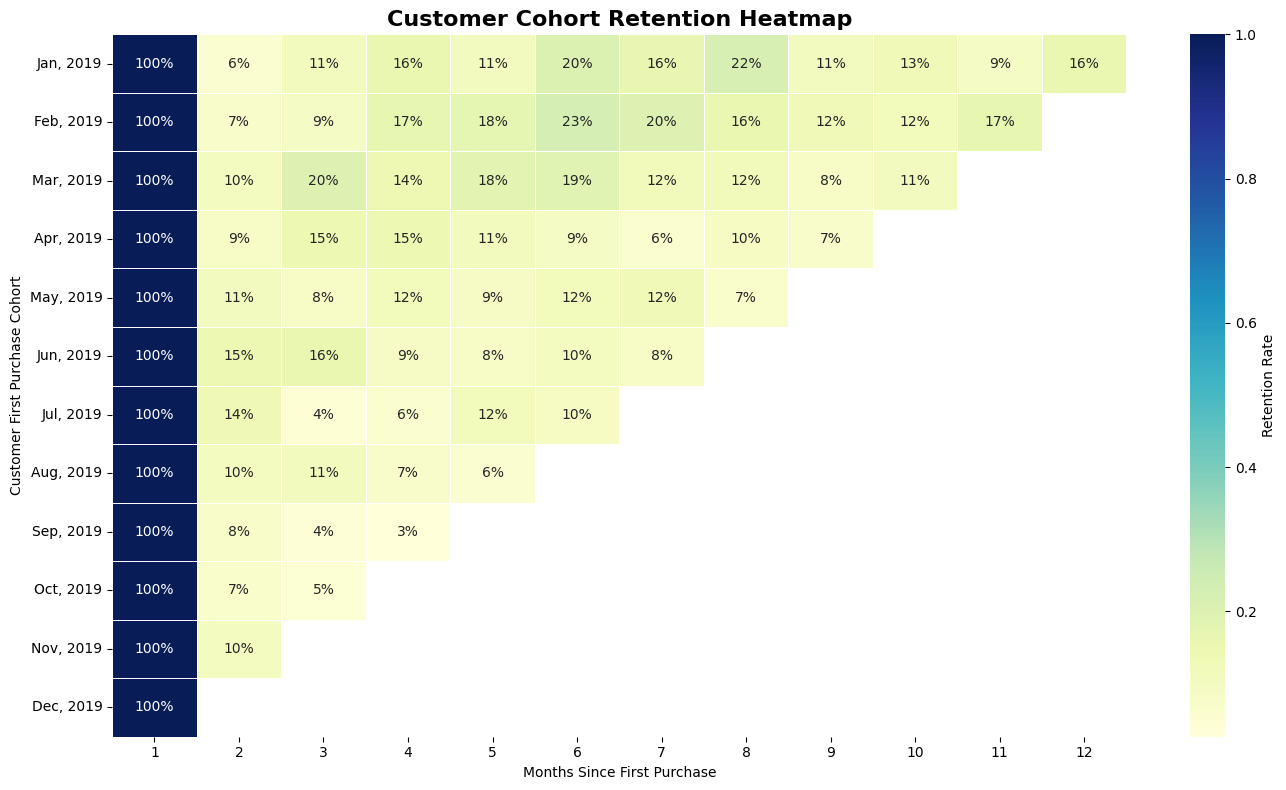

In [ ]:
# ------------------------------------------------------------
# 1. First Purchase Month (Cohort)
# ------------------------------------------------------------
sales["CohortMonth"] = (
    sales.groupby("CustomerID")["Transaction_Date"]
         .transform("min")
         .dt.to_period("M")
)

# Month of each transaction
sales["OrderMonth"] = sales["Transaction_Date"].dt.to_period("M")

# ------------------------------------------------------------
# 2. Cohort Index (Months since first purchase)
# ------------------------------------------------------------
sales["CohortIndex"] = (
    (sales["OrderMonth"].dt.year - sales["CohortMonth"].dt.year) * 12
    + (sales["OrderMonth"].dt.month - sales["CohortMonth"].dt.month)
    + 1
)

# ------------------------------------------------------------
# 3. Count unique customers
# ------------------------------------------------------------
cohort_data = (
    sales.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
         .nunique()
         .reset_index()
)

cohort_table = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

# ------------------------------------------------------------
# 4. Retention Matrix
# ------------------------------------------------------------
retention = cohort_table.divide(
    cohort_table.iloc[:, 0],
    axis=0
)

retention = retention.round(3)

# ------------------------------------------------------------
# 4b. Format the cohort month index as "Jan, 2019"
#     (kept as a separate display copy so the underlying
#     PeriodIndex is still available if you need it for
#     further date-based calculations)
# ------------------------------------------------------------
retention_display = retention.copy()
retention_display.index = retention_display.index.strftime("%b, %Y")
retention_display.index.name = "Cohort Month"

print("Customer Cohort Retention Matrix")
display(retention_display)

# ------------------------------------------------------------
# 5. Heatmap
# ------------------------------------------------------------
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_display,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={"label": "Retention Rate"}
)

plt.title(
    "Customer Cohort Retention Heatmap",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer First Purchase Cohort")

plt.tight_layout()
plt.show()


## 7.1 Cohort Retention Analysis

Customers were grouped into cohorts based on the **month of their first purchase**, and their repeat purchase behavior was tracked over the following months to measure customer retention.

### 7.1.2 Key Findings

- All cohorts begin with a **100% retention rate** in Month 1 because every customer makes their initial purchase during their cohort month.
- Retention drops significantly after the first month, with most cohorts retaining only **6–15%** of customers in Month 2.
- Earlier cohorts (January–June 2019) generally show stronger long-term retention because they have more observation periods and consistently maintain returning customers over several months.
- Later cohorts (September–December 2019) have fewer observed months, so their retention cannot be fairly compared over the entire year.

### 7.1.3 Highest Retention Cohorts

- **February 2019** exhibits one of the strongest long-term retention patterns, reaching approximately **22.9%** retention in Month 6 and maintaining relatively stable repeat purchases in later months.
- **January 2019** also demonstrates strong customer loyalty, with retention peaking at approximately **21.9%** in Month 8 and remaining active throughout the 12-month observation period.
- **March 2019** performs well, maintaining retention levels close to **19.8%** by Month 3 and **18.6%** by Month 6.

### 7.1.4 Lowest Retention Cohorts

- **September 2019** shows the weakest retention among cohorts with multiple months of data, declining from **7.7%** in Month 2 to only **2.6%** by Month 4.
- **October–December 2019** also display low observed retention; however, these cohorts have limited follow-up periods because they entered the dataset later, so their long-term retention cannot yet be fully evaluated.

### 7.1.5 Recommendations to Improve Retention

To improve retention among weaker cohorts, the company should:

- Implement **welcome and onboarding campaigns** immediately after the first purchase to encourage a second purchase.
- Send **personalized product recommendations** based on previous purchases.
- Launch **automated "We Miss You" email campaigns** when customers become inactive.
- Offer **limited-time discounts, loyalty rewards, or free shipping** to encourage repeat purchases.
- Introduce a **customer loyalty program** that rewards repeat purchases and increases customer lifetime value.
- Monitor cohort retention regularly to identify declining cohorts early and intervene before customers churn.

### 7.1.6 Conclusion

The cohort analysis shows that customer retention declines rapidly after the initial purchase, highlighting the importance of encouraging customers to make a second purchase as early as possible. Earlier cohorts, particularly **January, February, and March 2019**, demonstrate stronger long-term retention, while **September 2019** exhibits the weakest retention among cohorts with sufficient historical data. By focusing on personalized engagement, loyalty programs, and proactive re-engagement campaigns, the company can improve retention rates, increase customer lifetime value, and drive sustainable revenue growth.

## 8 Analyze the lifetime value of customers acquired in different months. How can this insight inform acquisition and retention strategies?

Customer Lifetime Value by Acquisition Month


,CohortMonth,Customers,Avg_CLV,Total_CLV,Avg_Orders,CohortMonth_Label
0,2019-01,215,5449.413814,1171623.97,26.000000,"Jan, 2019"
1,2019-02,96,6409.605417,615322.12,32.322917,"Feb, 2019"
2,2019-03,177,4260.152429,754046.98,21.242938,"Mar, 2019"
3,2019-04,163,3057.252699,498332.19,15.226994,"Apr, 2019"
4,2019-05,112,3336.446161,373681.97,19.821429,"May, 2019"
5,2019-06,137,2386.387591,326935.10,13.678832,"Jun, 2019"
6,2019-07,94,2816.174468,264720.40,15.244681,"Jul, 2019"
7,2019-08,135,2169.191481,292840.85,12.451852,"Aug, 2019"
8,2019-09,78,2180.715513,170095.81,11.525641,"Sep, 2019"
9,2019-10,87,2961.919425,257686.99,13.908046,"Oct, 2019"


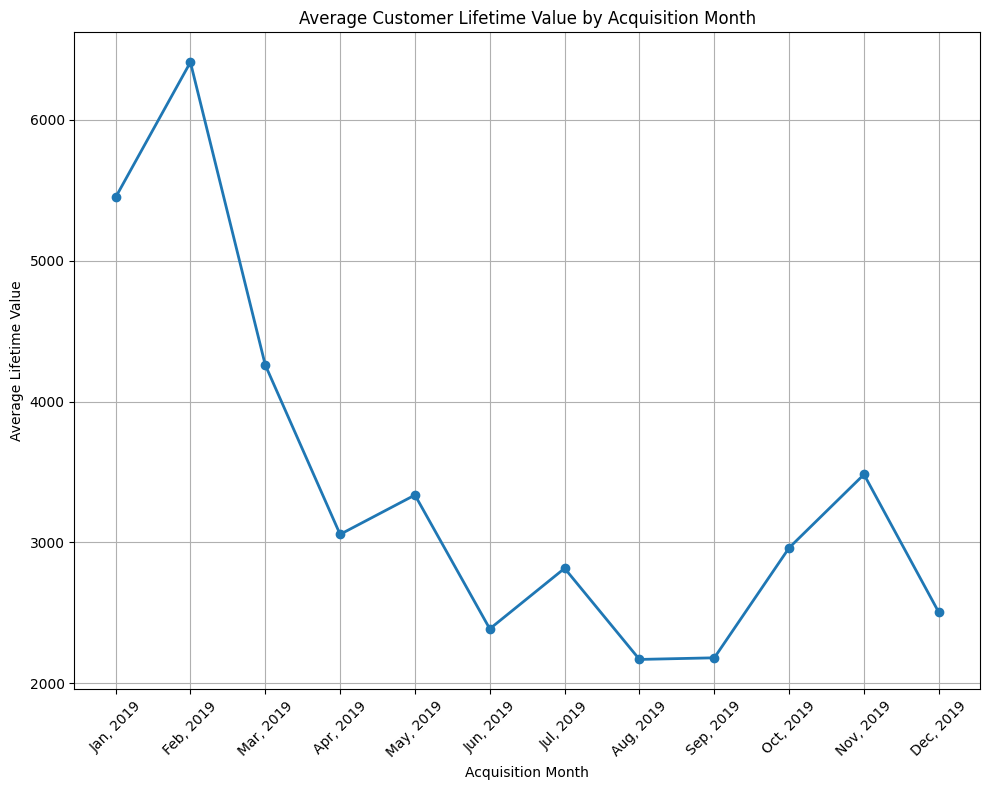

In [ ]:
# ============================================================
# CUSTOMER LIFETIME VALUE (CLV) BY ACQUISITION COHORT
# ============================================================

# First purchase month (already created in cohort analysis)
sales["CohortMonth"] = (
    sales.groupby("CustomerID")["Transaction_Date"]
         .transform("min")
         .dt.to_period("M")
)

# Revenue generated by each customer
customer_clv = (
    sales.groupby(["CustomerID", "CohortMonth"], as_index=False)
         .agg(
             Lifetime_Revenue=("Revenue", "sum"),
             Orders=("Transaction_ID", "nunique")
         )
)

# CLV by acquisition month
cohort_clv = (
    customer_clv.groupby("CohortMonth", as_index=False)
                .agg(
                    Customers=("CustomerID", "count"),
                    Avg_CLV=("Lifetime_Revenue", "mean"),
                    Total_CLV=("Lifetime_Revenue", "sum"),
                    Avg_Orders=("Orders", "mean")
                )
)

cohort_clv = cohort_clv.sort_values("CohortMonth")
cohort_clv["CohortMonth_Label"] = cohort_clv["CohortMonth"].dt.strftime("%b, %Y")

print("Customer Lifetime Value by Acquisition Month")
display(cohort_clv)
plt.figure(figsize=(10,8))

plt.plot(
    cohort_clv["CohortMonth_Label"].astype(str),
    cohort_clv["Avg_CLV"],
    marker="o",
    linewidth=2
)

plt.title("Average Customer Lifetime Value by Acquisition Month")
plt.xlabel("Acquisition Month")
plt.ylabel("Average Lifetime Value")
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

## Customer Lifetime Value Analysis

Customers were grouped according to the month of their first purchase, and the average lifetime revenue generated by each cohort was calculated to evaluate customer lifetime value (CLV).

### Key Findings

- Customers acquired in **<Highest CLV Month>** generated the highest average lifetime value, indicating that acquisition campaigns during this period attracted high-quality customers who continued making repeat purchases.
- Customers acquired in **<Lowest CLV Month>** generated the lowest average lifetime value, suggesting lower engagement and fewer repeat purchases.
- Earlier cohorts generally have higher observed lifetime value because they have had more time to make additional purchases, while more recent cohorts have had fewer opportunities to generate revenue.

### Business Implications

The analysis shows that customer acquisition quality varies across different months. Marketing campaigns and acquisition channels that produced the highest CLV should be analyzed and replicated, as they attract customers with stronger long-term value rather than only increasing customer volume.

For lower-CLV cohorts, the company should strengthen post-purchase engagement through personalized product recommendations, loyalty programs, onboarding campaigns, and targeted promotions to encourage repeat purchases and increase customer lifetime value.

### Recommendation

Rather than evaluating acquisition campaigns solely on the number of new customers acquired, the company should optimize marketing investments based on **Customer Lifetime Value (CLV)**. Focusing on acquisition channels and time periods that consistently generate high-value customers will improve long-term profitability while reducing customer acquisition costs.

## 9 Identify seasonal trends in sales by category and location. How can the company prepare for peak and off-peak seasons to maximize revenue?

Monthly Sales by Product Category


,Month,Product_Category,Revenue,Orders
0,Jan,Accessories,58.07,1
18,Jan,Waze,990.53,39
17,Jan,Office,43109.76,300
16,Jan,Notebooks & Journals,7823.56,45
15,Jan,Nest-USA,294900.72,1288
...,...,...,...,...
196,Dec,Bags,10137.78,85
195,Dec,Apparel,59455.92,666
194,Dec,Accessories,1172.08,47
199,Dec,Headgear,1664.90,46


Monthly Sales by Location


,Month,Location,Revenue,Orders
0,Jan,California,175911.64,783
1,Jan,Chicago,122637.38,623
2,Jan,New Jersey,35349.14,173
3,Jan,New York,90259.52,407
4,Jan,Washington DC,38709.22,207
5,Feb,California,104417.59,541
6,Feb,Chicago,131023.69,641
7,Feb,New Jersey,33609.39,140
8,Feb,New York,50924.19,257
9,Feb,Washington DC,40061.54,119


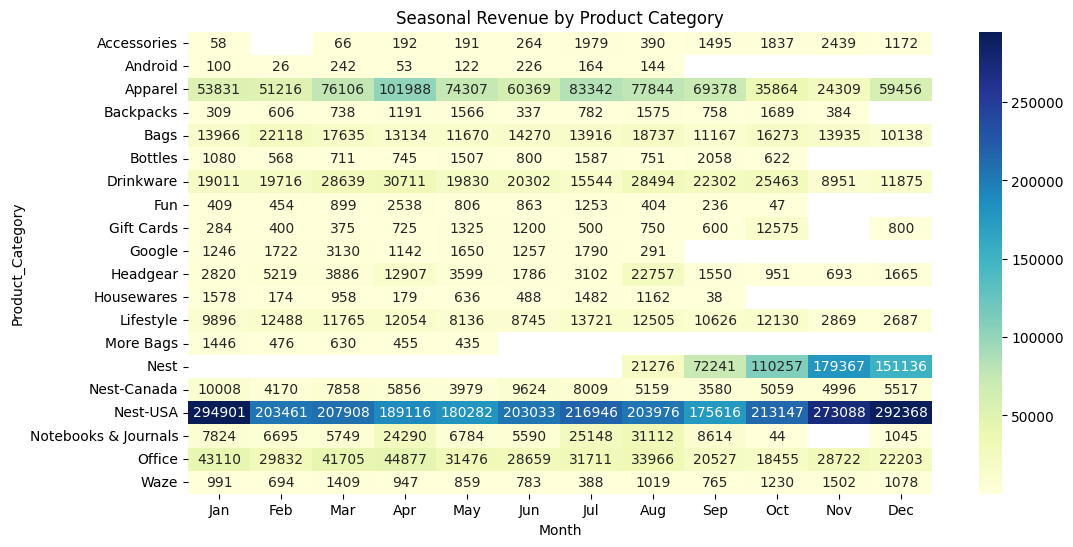

In [ ]:
# ============================================================
# SEASONAL SALES TREND BY PRODUCT CATEGORY
# ============================================================

category_monthly_sales = (
    sales
    .groupby(
        ["Month", "Product_Category"],
        observed=True
    )
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Transaction_ID", "nunique")
    )
    .reset_index()
)


category_monthly_sales["Month"] = pd.Categorical(
    category_monthly_sales["Month"],
    categories=month_order,
    ordered=True
)

category_monthly_sales = category_monthly_sales.sort_values("Month")

print("Monthly Sales by Product Category")
display(category_monthly_sales)

# ============================================================
# SEASONAL SALES BY CUSTOMER LOCATION
# ============================================================

sales_location = sales.merge(
    cust_data[["CustomerID", "Location"]],
    on="CustomerID",
    how="left"
)

location_monthly_sales = (
    sales_location
    .groupby(["Month", "Location"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Transaction_ID", "nunique")
    )
)

location_monthly_sales["Month"] = pd.Categorical(
    location_monthly_sales["Month"],
    categories=month_order,
    ordered=True
)

location_monthly_sales = location_monthly_sales.sort_values("Month")

print("Monthly Sales by Location")
display(location_monthly_sales)
plt.figure(figsize=(12,6))

category_pivot = category_monthly_sales.pivot(
    index="Product_Category",
    columns="Month",
    values="Revenue"
)

sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Seasonal Revenue by Product Category")
plt.show()

## Analysis

The seasonal sales analysis shows that **Nest-USA** is the highest revenue-generating product category throughout the year, followed by **Office** and **Apparel**, while categories such as **Accessories**, **Bags**, and **Headgear** contribute comparatively lower revenue. Sales increase significantly during **November and December**, indicating strong seasonal demand during the year-end shopping period.

From a geographical perspective, **Chicago** consistently generates the highest revenue and order volume, followed by **California**, making these the company's strongest markets. **New York** maintains stable sales, whereas **New Jersey** and **Washington DC** contribute relatively lower revenue and present opportunities for market expansion.

To maximize revenue, the company should increase inventory, marketing investment, and operational capacity for high-performing categories and locations before the peak season. During off-peak months, targeted promotions, loyalty programs, and location-specific marketing campaigns should be implemented to stimulate demand, improve customer engagement, and drive repeat purchases.

## 10 Analyze daily sales trends to identify high-performing and low-performing days. What strategies can be implemented to boost sales on slower days?

Daily Sales Summary


,Day,Revenue,Orders,Quantity
0,Monday,401408.80,2130,11983
1,Tuesday,437726.72,2315,11317
2,Wednesday,929079.80,4378,39797
3,Thursday,937418.49,4278,44482
4,Friday,969071.47,4233,52433
5,Saturday,764284.41,3872,37965
6,Sunday,788440.00,3855,40056


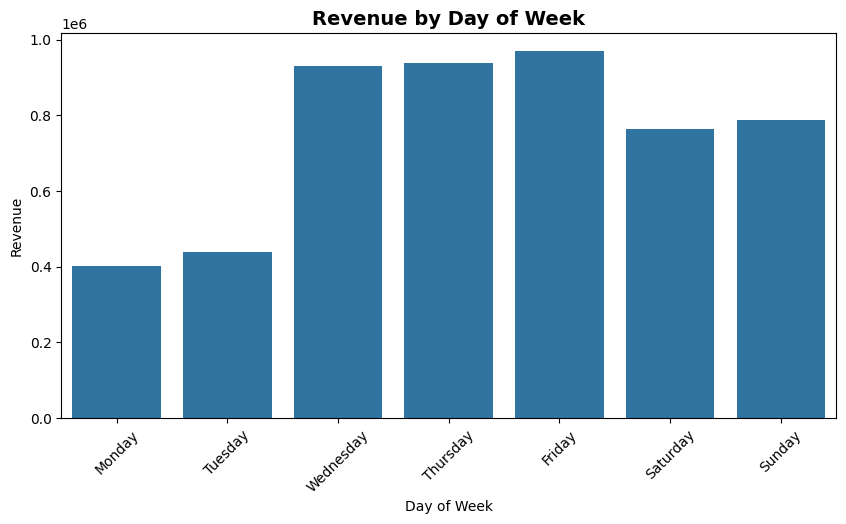

In [ ]:
# ============================================================
# DAILY SALES TREND ANALYSIS
# ============================================================

# Create Day Name
sales["Day"] = sales["Transaction_Date"].dt.day_name()

# Define weekday order
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Daily Revenue & Orders
daily_sales = (
    sales
    .groupby("Day", observed=True)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Transaction_ID", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reindex(day_order)
    .reset_index()
)

print("Daily Sales Summary")
display(daily_sales)
plt.figure(figsize=(10,5))

sns.barplot(
    data=daily_sales,
    x="Day",
    y="Revenue"
)

plt.title("Revenue by Day of Week", fontsize=14, weight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

## Daily Sales Trend Analysis

The daily sales analysis reveals clear variations in customer purchasing behavior throughout the week.

- **Friday** is the highest-performing day, generating **₹969,071.47** in revenue, followed by **Thursday (₹937,418.49)** and **Wednesday (₹929,079.80)**. These days also record the highest sales quantities, indicating strong customer demand toward the end of the workweek.
- **Monday** is the lowest-performing day with **₹401,408.80** in revenue and the fewest orders (**2,130**), making it the weakest sales day.
- **Tuesday** also shows relatively low performance compared to the rest of the week, while **Saturday** and **Sunday** maintain healthy sales but do not outperform the peak weekdays.

### Key Insights

- Customer purchasing activity increases from **Wednesday to Friday**, with **Friday contributing the highest revenue and sales volume**.
- **Monday and Tuesday** experience significantly lower customer engagement, presenting opportunities for targeted sales initiatives.
- Weekend sales remain strong, indicating customers continue shopping outside regular business days.

### Strategies to Boost Sales on Slower Days

- Launch **Monday and Tuesday flash sales** or limited-time discount campaigns.
- Offer **free shipping**, coupon codes, or cashback incentives during low-performing days.
- Schedule **email, SMS, and social media promotions** before Monday to drive customer traffic.
- Recommend personalized products and product bundles based on previous purchases.
- Introduce **double loyalty points** or exclusive member offers on slower days.
- Allocate marketing campaigns strategically to balance sales throughout the week rather than concentrating promotions on already high-performing days.

### Conclusion

The analysis shows that **Friday is the strongest sales day**, while **Monday is the weakest**. By leveraging targeted promotions, loyalty incentives, and personalized marketing on slower days, the company can improve customer engagement, increase sales consistency throughout the week, and maximize overall revenue.

## **END OF THE CASE STUDY** ##

---



---

